In [2]:
# Import packages
from typing import Optional
import phenograph
import scanpy as sc
from anndata import AnnData
from anndata import concat
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import os
import pandas as pd
import numpy as np
from scipy.stats import entropy
import subprocess
import palantir
import sys
import random
from collections import OrderedDict
import re
from itertools import chain
import warnings
sys.path.append('/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages')
#import harmony
from scipy.sparse import coo_matrix
from sklearn.neighbors import NearestNeighbors
from phenograph.core import find_neighbors, neighbor_graph, jaccard_kernel
from scipy.stats import zscore
import pandas as pd
import plotly.express as px
import matplotlib.font_manager
%matplotlib inline

In [1]:
# Read this excel file to identify ISC Module 29 genes
file_path = '/data/chanjlab/forsythb/organoid_analysis_pipeline_scripts/Supplementary_Table_1.xlsx'
df = pd.read_excel(file_path, sheet_name='1k')

# Assuming the correct column names, adjust if needed
module_column = 'Unnamed: 1'
gene_column = 'HotSpot Module Annotations'

# Filter genes based on the condition (Module == 29)
genes = df.loc[df[module_column] == 29, gene_column].tolist()

# Put those genes into a dictionary
gene_list = {'ISC_module29' : genes, }

NameError: name 'pd' is not defined

In [13]:
# This is the organoid dataset
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020624/adata.combined.postprocess.h5ad')

# Subset the organoid data
# Base media, liver metastasis
adata_base_liver = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'BASE') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Metastatic')]
# Base media, primary 
adata_base_primary = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'BASE') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Primary')]

# HISC media, liver metastasis
adata_hisc_liver = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'HISC') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Metastatic')]
# HISC media, primary
adata_hisc_primary = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'HISC') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Primary')]

# Dedifferentiated media, liver metastasis
adata_dedif_liver = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'Dedifferentiated') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Metastatic')]
# Dedifferentiated media, primary
adata_dedif_primary = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'Dedifferentiated') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Primary')]

In [16]:
# Compute gene scores
for gene_list_name, gene_list in gene_lists.items():
    score_name = f'{gene_list_name}_score'
    sc.tl.score_genes(adata_hisc_primary, gene_list=gene_list, score_name=score_name)
    
    # Add score to adata
    adata_hisc_primary.obs[score_name] = zscore(adata_hisc_primary.obs[score_name])

In [34]:
probabilities = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/harmony_phenograph.020724/hisc_primary_pval_df_sum.csv', index_col=0)

In [46]:
probs = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/harmony_phenograph.020724/adata_phenograph_base_liver.csv', index_col=0)

In [50]:
p = probs.loc[:,['SCC','Early NET','Fetal Progenitor','Injury Repair']].sum(axis=1)

In [18]:
adata_hisc_primary.obs['ISC_module29_score']

146P_HISC_shZFP36L2_4_GTGCAGCAGAGAGGGC-1   -0.138392
146P_HISC_shCTRL_TGCAGATAGTCTACCA-1         2.646717
146P_HISC_shCTRL_AAGAACAAGGACACTG-1         0.858066
146P_HISC_shCTRL_GAATAGACAGGGATAC-1         1.334229
146P_HISC_shZFP36L2_4_ACATCCCTCGCCACTT-1   -0.587693
                                              ...   
146P_HISC_shCTRL_GCTACAACACGATTCA-1         0.027658
146P_HISC_shZFP36L2_4_GAGTGTTTCCTGTAAG-1   -1.113024
146P_HISC_shZFP36L2_4_CCTCCTCCATATGGCT-1   -0.056207
146P_HISC_shZFP36L2_4_ATGTCTTCAGTCCCGA-1    1.497401
146P_HISC_shCTRL_CCTCACAGTTGGTGTT-1        -0.019111
Name: ISC_module29_score, Length: 9688, dtype: float64

### Plot DEGs on UMAP

In [2]:
# This is the organoid dataset
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020624/adata.combined.postprocess.h5ad')

In [3]:
adata_organoid

AnnData object with n_obs × n_vars = 50906 × 31586
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_umap', 'gene_expression_encoding'
    layers: 'w

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

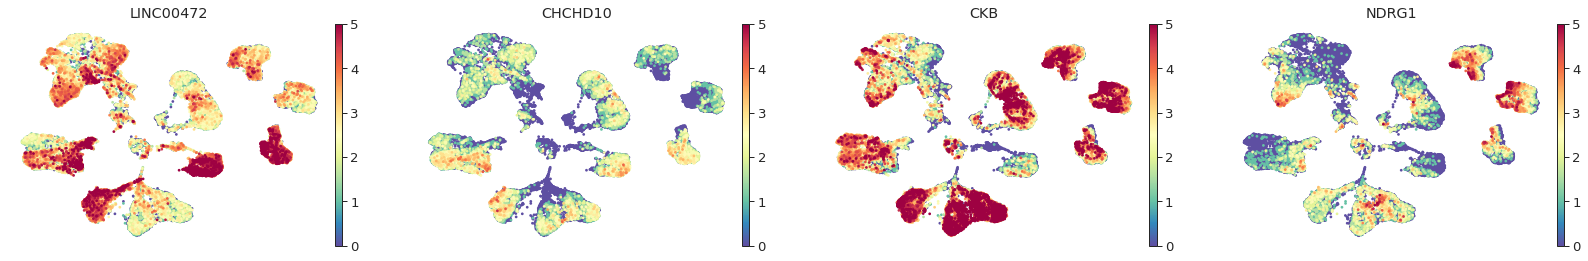

In [6]:
sc.pl.umap(adata_organoid, 
           color=['LINC00472',
                'CHCHD10',
                'CKB',
                'NDRG1',],
           cmap = 'Spectral_r',
           vmin=[0],
           vmax= [5],
           s=30,
           use_raw = False,
           frameon = False)

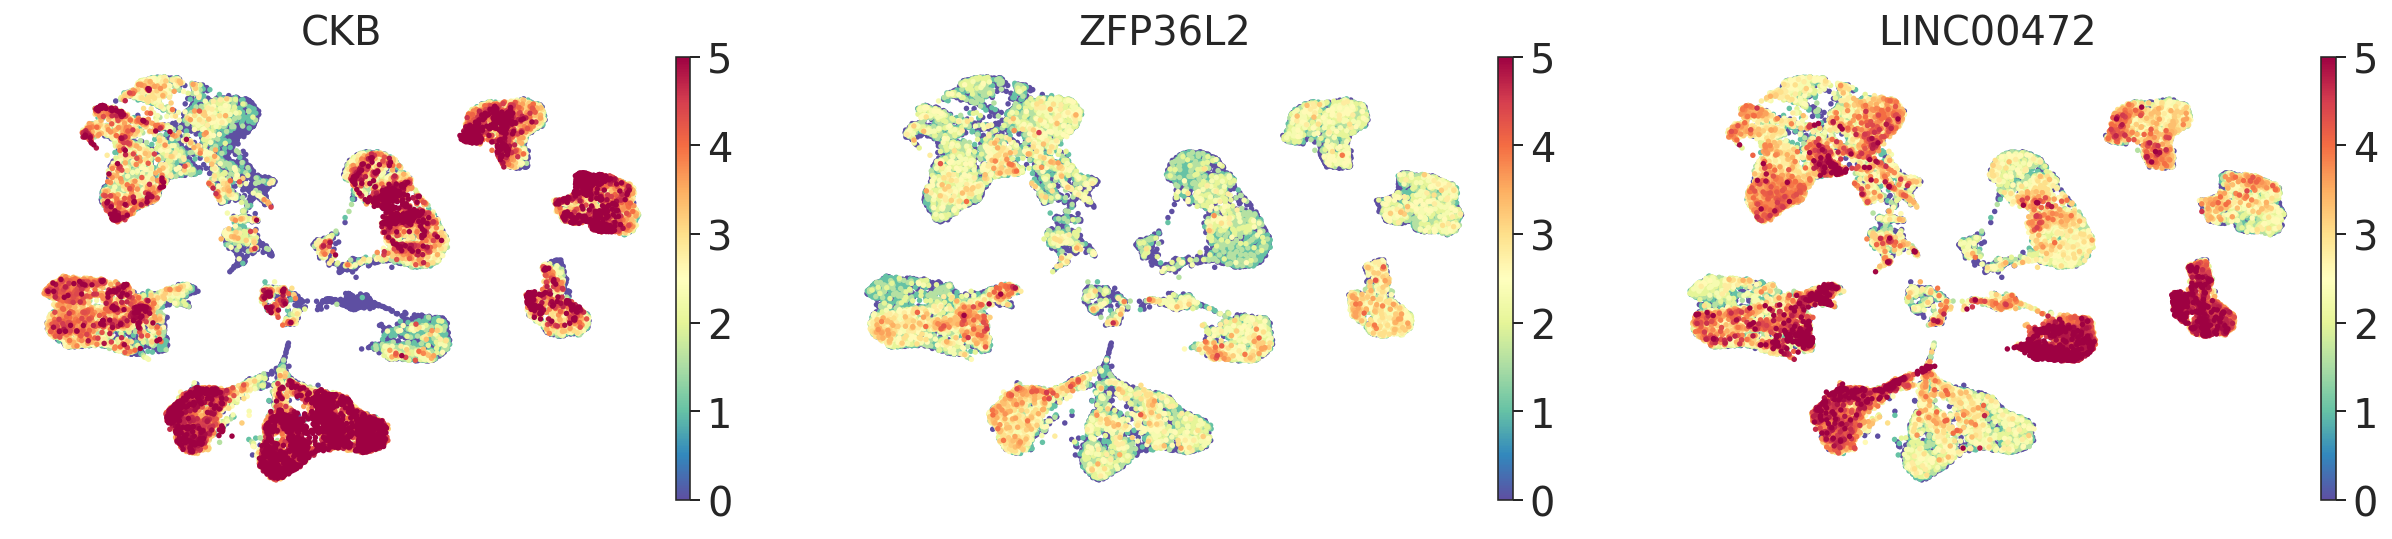

In [35]:
sc.pl.umap(adata_organoid, 
           color=['CKB',
                'ZFP36L2',
                'LINC00472',],
           cmap = 'Spectral_r',
           vmin=[0],
           vmax= [5],
           s=30,
           use_raw = False,
           frameon = False)

In [3]:
# Read in adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output.042224/adata.organoid.combined.042224.h5ad')

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary in Patient 146')

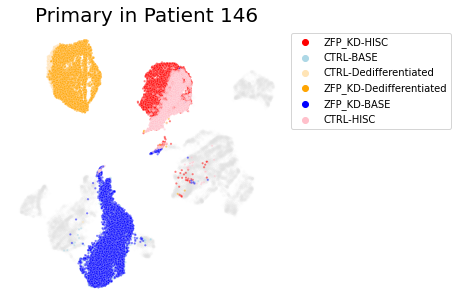

In [28]:
color_labels = {}
for col, j in zip(['blue','red','orange'],['BASE','HISC','Dedifferentiated']):
    for shade,i in zip(['light',''],['CTRL','ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
        if color_labels[i + '-' + j] =='darkred':
            color_labels[i + '-' + j] = 'orange'
        if color_labels[i + '-' + j] =='lightorange':
            color_labels[i + '-' + j] = 'moccasin'


fig, ax=plt.subplots(1,1, figsize=(5,5))

# ind1 = adata.obs.Tumor_Site=='Primary'
# ind2 = adata.obs.Culture_Media!='Dedifferentiated'
# ind = ind1.values & ind2.values

ind1 = adata.obs.Tumor_Site=='Primary'
#ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

# plt.scatter(plot_df.loc[~ind,'x'], plot_df.loc[~ind,'y'], color='gainsboro', s=3, marker='x')
plt.scatter(plot_df.loc[~ind,'x'], plot_df.loc[~ind,'y'], color='gainsboro', s=5, edgecolor=None, alpha=0.03)


# sns.scatterplot(data=plot_df.loc[ind,:], x='x',y='y', style='Patient', hue='Condition',
#                     markers = {125: 'o', 146: 'X'},
#                     palette = color_labels, ax=ax)

sns.scatterplot(data=plot_df.loc[ind,:], x='x',y='y', hue='Condition',
                s=5,edgecolor='white',
                palette = color_labels, ax=ax,
                alpha=0.5)

ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary in Patient 146',fontsize=20)

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Metastasis in Patient 146')

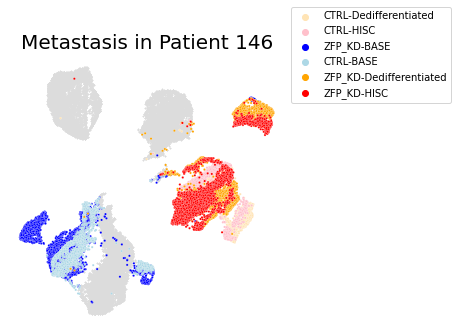

In [27]:
fig, ax=plt.subplots(1,1, figsize=(5,5))

ind = adata.obs.Tumor_Site=='Metastatic'

umap = adata.obsm['X_umap']
# plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df = adata.obs.loc[:,['Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)


plt.scatter(plot_df.loc[~ind,'x'], plot_df.loc[~ind,'y'], color='gainsboro', s=1, marker='x')

g = sns.scatterplot(data=plot_df.loc[ind,:], x='x',y='y', hue='Condition',
                    s=5,edgecolor='white',
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='center left')
ax.set_title('Metastasis in Patient 146',fontsize=20)

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib

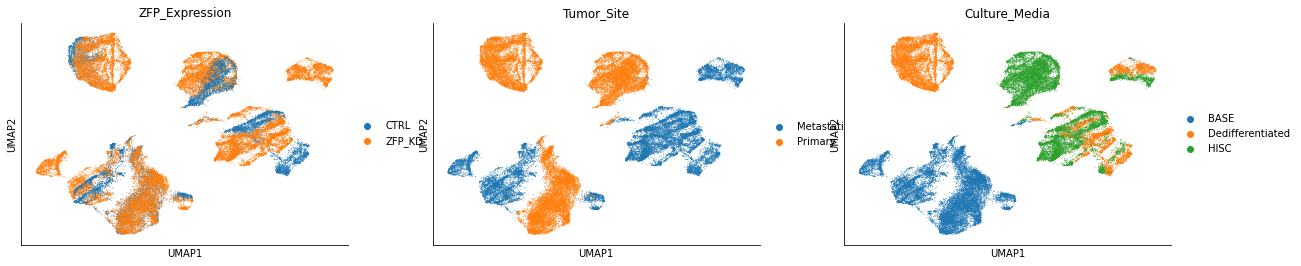

In [14]:
sc.pl.umap(adata, 
          color=['ZFP_Expression', 'Tumor_Site', 'Culture_Media'])

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

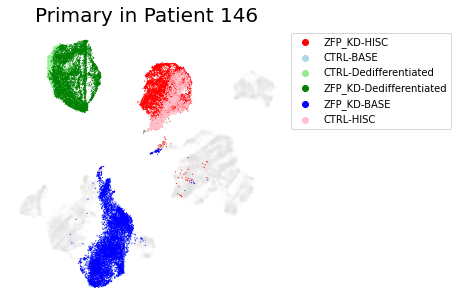

In [19]:
import os
import re
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Plot color labels
color_labels = {}
for col, j in zip(['blue', 'red', 'green'], ['BASE', 'HISC', 'Dedifferentiated']):
    for shade, i in zip(['light', ''], ['CTRL', 'ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] == 'lightred':
            color_labels[i + '-' + j] = 'pink'
        if color_labels[i + '-' + j] == 'darkred':
            color_labels[i + '-' + j] = 'orange'
        if color_labels[i + '-' + j] == 'lightorange':
            color_labels[i + '-' + j] = 'moccasin'

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Filter indices
ind1 = adata.obs.Tumor_Site == 'Primary'
ind = ind1.values

# UMAP coordinates
umap = adata.obsm['X_umap']

# Dataframe for plotting
plot_df = adata.obs.loc[:, ['Patient', 'Culture_Media', 'ZFP_Expression']]
plot_df['x'] = umap[:, 0].tolist()
plot_df['y'] = umap[:, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

# Scatter plot for background points
plt.scatter(plot_df.loc[~ind, 'x'], plot_df.loc[~ind, 'y'], color='gainsboro', s=5, edgecolor=None, alpha=0.03)

# Scatter plot for main data
sns.scatterplot(data=plot_df.loc[ind, :], x='x', y='y', hue='Condition',
                s=1, edgecolor=None,
                palette=color_labels, ax=ax, zorder=10)  # Higher zorder for main data

# Customize plot
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('Primary in Patient 146', fontsize=20)

plt.show()


In [20]:
sc.tl.score_genes(adata_organoid, ['CKB', 'ZFP36L2', 'LINC00472'], score_name='S_score')

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

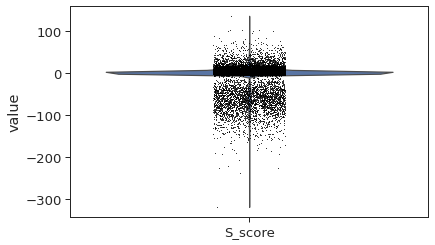

In [18]:
sc.pl.violin(adata_organoid, keys='S_score', group_by='ZFP_Expression')

In [16]:
adata_organoid

AnnData object with n_obs × n_vars = 50906 × 31586
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden', 'S_score'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_umap', 'gene_expression_encoding'
   

In [23]:
sc.set_figure_params(fontsize=20)
sns.set_style('ticks')

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprec

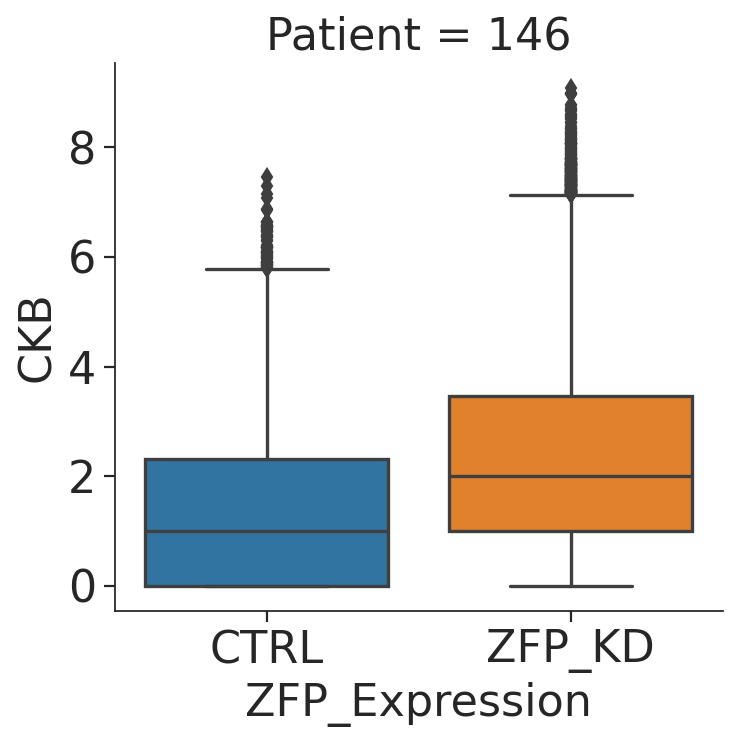

In [28]:
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020624/adata.combined.postprocess.h5ad')
plot_df = adata_organoid.obs
plot_df.loc[:,'CKB'] = adata_organoid.X.todense()[:,adata_organoid.var_names=='CKB']
sns.catplot(data=plot_df, x='ZFP_Expression', y='CKB', col='Patient', kind='box')

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprec

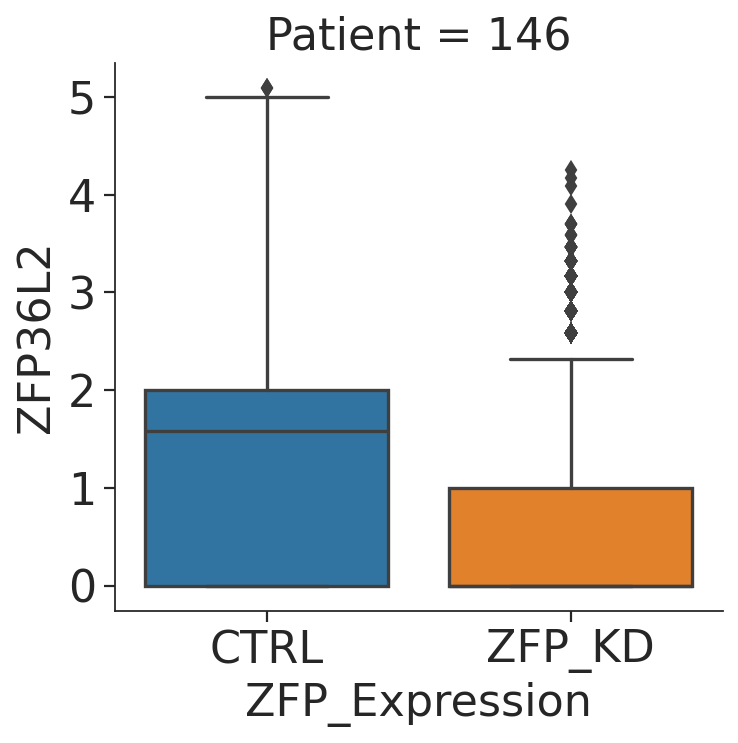

In [29]:
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020624/adata.combined.postprocess.h5ad')
plot_df = adata_organoid.obs
plot_df.loc[:,'ZFP36L2'] = adata_organoid.X.todense()[:,adata_organoid.var_names=='ZFP36L2']
sns.catplot(data=plot_df, x='ZFP_Expression', y='ZFP36L2', col='Patient', kind='box')

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprec

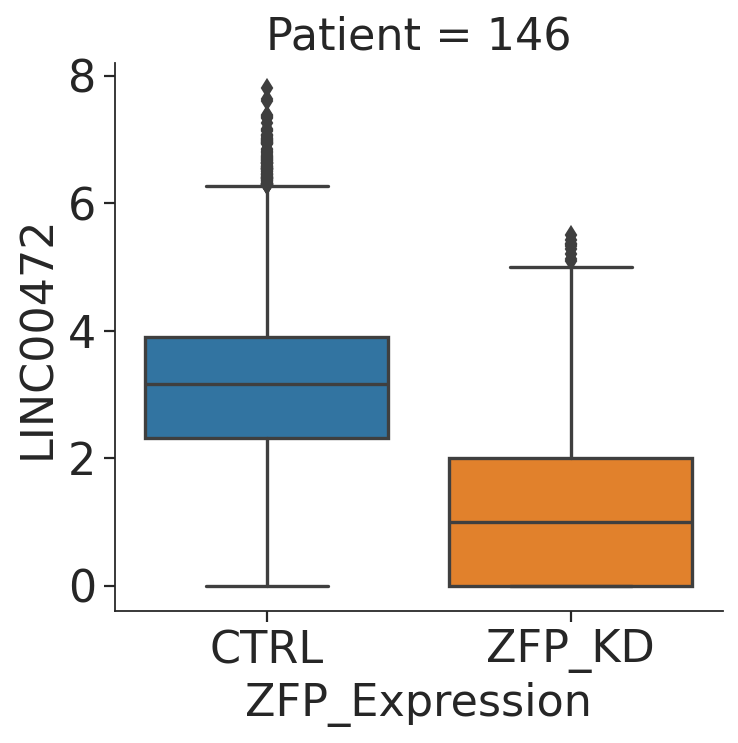

In [30]:
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020624/adata.combined.postprocess.h5ad')
plot_df = adata_organoid.obs
plot_df.loc[:,'LINC00472'] = adata_organoid.X.todense()[:,adata_organoid.var_names=='LINC00472']
sns.catplot(data=plot_df, x='ZFP_Expression', y='LINC00472', col='Patient', kind='box')